# COMP6010 Part B — Learning robot-grasp reliability

Part A used known model probabilities. Here, the robot's success probability is **unknown**.
We represent uncertainty about it using a Beta distribution and update that distribution from observations.
This guided notebook covers **B1–B4** of COMP6010_Assignment_2026.docx.

Upload to Colab and run the cells in order using Python 3 on **CPU**. No GPU, dataset download, API key,
or Part A variables are needed. Required packages: NumPy, pandas, Matplotlib and SciPy.
If a package is missing, install it in a separate cell using %pip install numpy pandas matplotlib scipy.

Saved outputs show assistant-side CPU verification. Rerun in Colab for your own evidence and complete the
reflection prompts in your own words. Save your executed notebook separately from the result ZIP.
The data are hypothetical teaching observations. This is not a real deployment recommendation.

## 1. Define the learning problem — B1

- $X_i$ is the **outcome** of attempt i: 1 for success, 0 for failure.
- $\theta$ is the **unknown success probability**, assumed fixed across the batches.
- $\mathcal D$ denotes all observations available so far.

$$X_i\mid\theta\sim\operatorname{Bernoulli}(\theta),\qquad
P(X_i=x\mid\theta)=\theta^x(1-\theta)^{1-x},\quad x\in\{0,1\}.$$

Bernoulli is appropriate for a binary outcome. The Beta distribution describes uncertainty about a
probability on (0,1) and combines conveniently with the Bernoulli likelihood:

$$\theta\sim\operatorname{Beta}(\alpha_0,\beta_0),\qquad
p(\theta)=\frac{\theta^{\alpha_0-1}(1-\theta)^{\beta_0-1}}{B(\alpha_0,\beta_0)}.$$

The required prior is **Beta(2,3)**. Its shape parameters are prior settings, not recorded robot attempts.
$B(\alpha_0,\beta_0)$ normalises the density; its derivation is not required.

The robot settings and evaluation conditions remain unchanged. Attempts are **conditionally independent
given $\theta$**: $X_i\perp X_j\mid\theta$ for $i\ne j$. Hence
$p(\theta,X_1,\ldots,X_n)=p(\theta)\prod_i p(X_i\mid\theta)$.
After integrating out the shared unknown parameter, outcomes generally are not marginally independent:
one observed success changes our belief about reliability and therefore future predictions.

In [1]:
from pathlib import Path
import importlib.metadata
import json
import platform
import shutil
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.integrate import quad

OUT = Path('COMP6010_Part_B_outputs')
OUT.mkdir(exist_ok=True)
VERSIONS = {name: importlib.metadata.version(name) for name in ['numpy','pandas','matplotlib','scipy']}
plt.rcParams.update({'figure.dpi':120, 'font.size':11})
print('Python:', sys.version.split()[0])
print('Packages:', VERSIONS)
print('Platform:', platform.platform())

ALPHA0, BETA0 = 2, 3
# Each row contains NEW observations, not cumulative counts.
BATCHES = pd.DataFrame({'batch':[1,2,3], 'attempts':[10,20,70],
                        'successes':[6,16,63], 'failures':[4,4,7]})
assert (BATCHES.successes+BATCHES.failures).equals(BATCHES.attempts)
assert BATCHES[['attempts','successes','failures']].ge(0).all().all()
print('\nNew data in each batch:')
print(BATCHES.to_string(index=False))

Python: 3.13.15
Packages: {'numpy': '2.1.3', 'pandas': '2.2.3', 'matplotlib': '3.10.0', 'scipy': '1.16.3'}
Platform: Linux-6.6.122+-x86_64-with-glibc2.39

New data in each batch:
 batch  attempts  successes  failures
     1        10          6         4
     2        20         16         4
     3        70         63         7


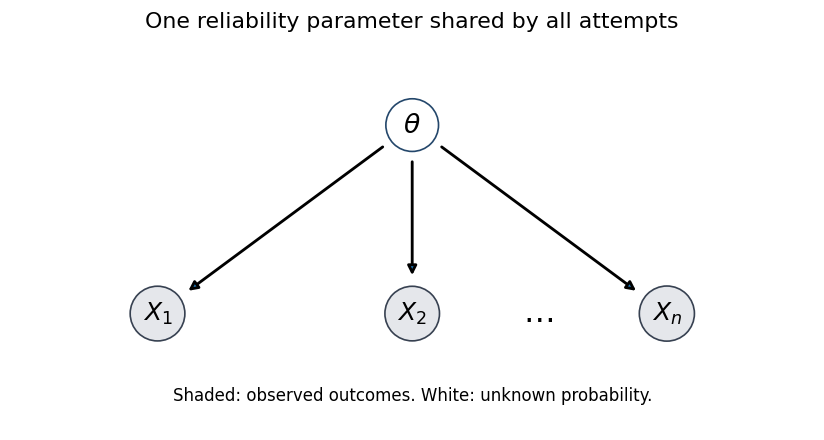

In [2]:
# Shared unknown parameter and representative observed outcomes.
fig, ax = plt.subplots(figsize=(7,3.8))
for x,label in [(-1.4,r'$X_1$'),(0,r'$X_2$'),(1.4,r'$X_n$')]:
    ax.annotate('', xy=(x,0), xytext=(0,1.4),
                arrowprops={'arrowstyle':'-|>','lw':1.7,'shrinkA':22,'shrinkB':23})
    ax.text(x,0,label,ha='center',va='center',fontsize=15,
            bbox={'boxstyle':'circle,pad=0.5','fc':'#e5e7eb','ec':'#374151'})
ax.text(0,1.4,r'$\theta$',ha='center',va='center',fontsize=16,
        bbox={'boxstyle':'circle,pad=0.5','fc':'white','ec':'#24476b'})
ax.text(0.7,0,'…',ha='center',va='center',fontsize=19)
ax.text(0,-0.65,'Shaded: observed outcomes. White: unknown probability.',ha='center',fontsize=10)
ax.set(xlim=(-2.2,2.2),ylim=(-0.85,2.05),title='One reliability parameter shared by all attempts')
ax.axis('off')
fig.tight_layout()
fig.savefig(OUT/'beta_bernoulli_graph.png',dpi=200)
plt.show()

## 2. Derive the posterior update — B2

Let s be cumulative successes, f cumulative failures, and n=s+f cumulative attempts.
The likelihood for the observed sequence is

$$L(\theta;\mathcal D)=\prod_i\theta^{x_i}(1-\theta)^{1-x_i}
=\theta^s(1-\theta)^f.$$

If represented as binomial batch counts, combinatorial factors also appear. They do not depend on
$\theta$, so they cancel in posterior normalisation and do not change the update.

Bayes' rule gives
$$p(\theta\mid\mathcal D)=\frac{L(\theta;\mathcal D)p(\theta)}{p(\mathcal D)}
\propto\theta^{s+\alpha_0-1}(1-\theta)^{f+\beta_0-1}.$$

Recognising a Beta kernel yields
$$\theta\mid\mathcal D\sim\operatorname{Beta}(\alpha_0+s,\beta_0+f).$$

**Sequential:** add only the new batch counts to the current shapes.
**Pooled:** add all observed counts once to the original prior.
Adding cumulative counts to an already updated posterior would double-count the data.

With posterior shapes $\alpha=\alpha_0+s$ and $\beta=\beta_0+f$, the point estimates are
$$\widehat\theta_{\mathrm{ML}}=\frac{s}{n},\qquad
E[\theta\mid\mathcal D]=\frac{\alpha}{\alpha+\beta},\qquad
\widehat\theta_{\mathrm{MAP}}=\frac{\alpha-1}{\alpha+\beta-2}.$$

The MAP formula needs both shapes greater than 1, which holds in all cases here.
ML maximises the likelihood, MAP maximises posterior density, and the posterior mean averages
over the distribution of possible parameter values.

In [3]:
def update_beta(alpha,beta_shape,successes,failures):
    """Add NEW observation counts to current Beta shapes."""
    if alpha<=0 or beta_shape<=0:
        raise ValueError('Beta shapes must be positive.')
    if any(v<0 or int(v)!=v for v in (successes,failures)):
        raise ValueError('Counts must be nonnegative integers.')
    return alpha+int(successes), beta_shape+int(failures)

def estimate_row(batch,alpha,beta_shape,successes,failures):
    """Return cumulative counts, posterior shapes and point estimates."""
    if alpha<=1 or beta_shape<=1:
        raise ValueError('Interior MAP formula requires shapes > 1.')
    n=successes+failures
    return {'batch':batch,'cumulative_attempts':n,'cumulative_successes':successes,
            'cumulative_failures':failures,'alpha':alpha,'beta':beta_shape,
            'ML':successes/n,'posterior_mean':alpha/(alpha+beta_shape),
            'MAP':(alpha-1)/(alpha+beta_shape-2)}

alpha,beta_shape=ALPHA0,BETA0
successes,failures=0,0
records=[]
for batch in BATCHES.itertuples(index=False):
    alpha,beta_shape=update_beta(alpha,beta_shape,batch.successes,batch.failures)
    successes+=batch.successes
    failures+=batch.failures
    assert (alpha,beta_shape)==update_beta(ALPHA0,BETA0,successes,failures)
    records.append(estimate_row(batch.batch,alpha,beta_shape,successes,failures))
updates=pd.DataFrame(records)
assert list(zip(updates.alpha,updates.beta))==[(8,7),(24,11),(87,18)]
assert (successes,failures)==(85,15)
FINAL_ALPHA,FINAL_BETA=alpha,beta_shape
print(updates.to_string(index=False,float_format=lambda x:f'{x:.9f}'))
print('\nPassed: sequential and pooled updates agree after every batch.')
BATCHES.to_csv(OUT/'input_batches.csv',index=False)
updates.to_csv(OUT/'posterior_updates.csv',index=False)

 batch  cumulative_attempts  cumulative_successes  cumulative_failures  alpha  beta          ML  posterior_mean         MAP
     1                   10                     6                    4      8     7 0.600000000     0.533333333 0.538461538
     2                   30                    22                    8     24    11 0.733333333     0.685714286 0.696969697
     3                  100                    85                   15     87    18 0.850000000     0.828571429 0.834951456

Passed: sequential and pooled updates agree after every batch.


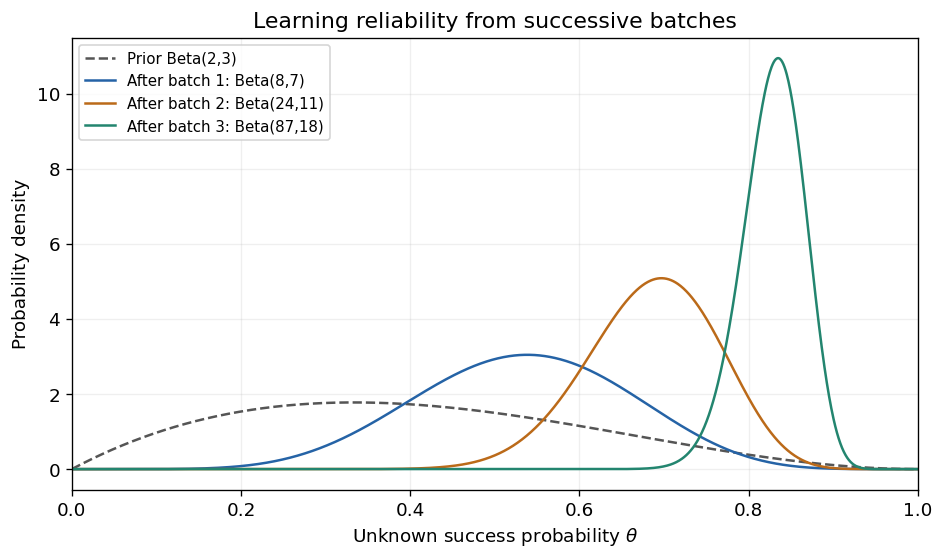

In [4]:
grid=np.linspace(0.0001,0.9999,1500)
fig,ax=plt.subplots(figsize=(8,4.8))
ax.plot(grid,beta.pdf(grid,ALPHA0,BETA0),color='#555555',linestyle='--',label='Prior Beta(2,3)')
for row,color in zip(updates.itertuples(index=False),['#2563a6','#bb6a19','#23856f']):
    ax.plot(grid,beta.pdf(grid,row.alpha,row.beta),color=color,
            label=f'After batch {row.batch}: Beta({row.alpha},{row.beta})')
ax.set(xlim=(0,1),xlabel=r'Unknown success probability $\theta$',ylabel='Probability density',
       title='Learning reliability from successive batches')
ax.grid(alpha=0.2)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUT/'prior_and_posteriors.png',dpi=200)
fig.savefig(OUT/'prior_and_posteriors.pdf')
plt.show()

## 3. Uncertainty and the deployment rule — B3

These quantities answer different questions:

| Quantity | Calculation | Meaning |
|---|---|---|
| Next-attempt success probability | $E[\theta\mid\mathcal D]$ | Predictive probability after accounting for parameter uncertainty |
| 95% equal-tailed credible interval | Beta quantiles at 0.025 and 0.975 | Interval with 95% posterior probability for $\theta$ |
| $P(\theta>0.8\mid\mathcal D)$ | Posterior area from 0.8 to 1 | Probability reliability exceeds the threshold |

The posterior predictive probability is
$$P(X_{n+1}=1\mid\mathcal D)=\int_0^1P(X_{n+1}=1\mid\theta)p(\theta\mid\mathcal D)d\theta
=\int_0^1\theta\,p(\theta\mid\mathcal D)d\theta=\frac{\alpha}{\alpha+\beta}.$$

The assignment's hypothetical rule requires $P(\theta>0.8\mid\mathcal D)\ge0.95$.
SciPy's beta.sf evaluates this right-tail area; beta.ppf gives quantiles.
beta.pdf at 0.8 returns a **density height**, not the tail probability. A density can exceed 1.
For a continuous parameter, the probability of exactly one specified value is zero.

Before running, record a prediction:

- My prediction about the deployment decision and why: **[complete]**.
- My prediction about Monte Carlo versus the analytical probability: **[complete]**.
- Date and whether I have already seen saved outputs: **[complete honestly]**.

If you already saw the saved results, predict a new seed run instead of claiming an earlier prediction.

In [5]:
THRESHOLD=0.8
REQUIRED_PROBABILITY=0.95
predictive=FINAL_ALPHA/(FINAL_ALPHA+FINAL_BETA)
lower,upper=beta.ppf([0.025,0.975],FINAL_ALPHA,FINAL_BETA)
tail_probability=float(beta.sf(THRESHOLD,FINAL_ALPHA,FINAL_BETA))
meets_rule=tail_probability>=REQUIRED_PROBABILITY
decision=pd.DataFrame([{'posterior_alpha':FINAL_ALPHA,'posterior_beta':FINAL_BETA,
    'next_attempt_success_probability':predictive,'credible_interval_lower':lower,
    'credible_interval_upper':upper,'threshold':THRESHOLD,
    'probability_theta_above_threshold':tail_probability,'required_probability':REQUIRED_PROBABILITY,
    'meets_deployment_rule':meets_rule}])
print(f'Final posterior: Beta({FINAL_ALPHA}, {FINAL_BETA})')
print(f'Next-attempt success probability: {predictive:.9f}')
print(f'95% equal-tailed credible interval: [{lower:.9f}, {upper:.9f}]')
print(f'P(theta > 0.8 | data): {tail_probability:.9f}')
print(f'Deployment requirement met: {meets_rule}')
print(f'Density height at 0.8 (NOT a probability): {beta.pdf(THRESHOLD,FINAL_ALPHA,FINAL_BETA):.6f}')
assert np.allclose(beta.cdf([lower,upper],FINAL_ALPHA,FINAL_BETA),[0.025,0.975])
assert np.isclose(beta.cdf(THRESHOLD,FINAL_ALPHA,FINAL_BETA)+tail_probability,1.0)
decision.to_csv(OUT/'uncertainty_and_decision.csv',index=False)

Final posterior: Beta(87, 18)
Next-attempt success probability: 0.828571429
95% equal-tailed credible interval: [0.751231581, 0.894075803]
P(theta > 0.8 | data): 0.788266659
Deployment requirement met: False
Density height at 0.8 (NOT a probability): 7.255623


## 4. Verify using posterior draws — B3

Draw $\theta^{(m)}\sim\operatorname{Beta}(87,18)$, and estimate
$$\widehat p=\frac1M\sum_{m=1}^M\mathbf1[\theta^{(m)}>0.8].$$

We use **100,000 draws** (above the required 10,000) and seed **6010**. These are possible parameter
values drawn from the posterior, not newly observed robot attempts. More draws improve numerical precision;
they do not provide more evidence about the robot.

The approximate Monte Carlo standard error is $\sqrt{\widehat p(1-\widehat p)/M}$.
It measures simulation error in the probability estimate, not the credible interval for $\theta$.
Exact equality with the analytical probability is not expected.

In [6]:
MC_SEED=6010
POSTERIOR_DRAWS=100_000
rng=np.random.default_rng(MC_SEED)
draws=rng.beta(FINAL_ALPHA,FINAL_BETA,size=POSTERIOR_DRAWS)
mc_probability=float(np.mean(draws>THRESHOLD))
mc_se=float(np.sqrt(mc_probability*(1-mc_probability)/POSTERIOR_DRAWS))
mc_error=abs(mc_probability-tail_probability)
mc=pd.DataFrame([{'seed':MC_SEED,'draws':POSTERIOR_DRAWS,
    'analytic_tail_probability':tail_probability,'monte_carlo_probability':mc_probability,
    'absolute_error':mc_error,'monte_carlo_standard_error':mc_se,
    'error_in_standard_errors':mc_error/mc_se}])
print(mc.to_string(index=False,float_format=lambda x:f'{x:.9f}'))
print(f'Sample mean: {draws.mean():.9f}; analytical mean: {predictive:.9f}')
print('Agreement within five MC standard errors:',mc_error<=5*mc_se)
# Report unusual disagreement; do not repeatedly change seeds to force agreement.
assert POSTERIOR_DRAWS>=10_000
assert np.all((draws>=0)&(draws<=1))
mc.to_csv(OUT/'monte_carlo_verification.csv',index=False)
np.save(OUT/'posterior_draws.npy',draws)

 seed  draws  analytic_tail_probability  monte_carlo_probability  absolute_error  monte_carlo_standard_error  error_in_standard_errors
 6010 100000                0.788266659              0.789660000     0.001393341                 0.001288787               1.081125931
Sample mean: 0.828681071; analytical mean: 0.828571429
Agreement within five MC standard errors: True


## 5. Independently check the posterior calculation

This cell reconstructs the unnormalised prior-times-likelihood kernel from the original prior and counts.
Numerical integration then obtains its mean, threshold area and credible-interval mass without calling
the Beta PDF or CDF. Subtracting the log-kernel at its mode keeps the exponentials stable; the scale
cancels when the integrals are divided.

In [7]:
s=int(BATCHES.successes.sum())
f=int(BATCHES.failures.sum())
success_exponent=ALPHA0-1+s
failure_exponent=BETA0-1+f
mode=success_exponent/(success_exponent+failure_exponent)
log_scale=success_exponent*np.log(mode)+failure_exponent*np.log1p(-mode)

def scaled_posterior_kernel(theta):
    """Prior x likelihood, up to a constant; no scipy.stats.beta calls."""
    if theta<=0 or theta>=1:
        return 0.0  # Both exponents are positive in this assignment.
    return float(np.exp(success_exponent*np.log(theta)+failure_exponent*np.log1p(-theta)-log_scale))

normaliser=quad(scaled_posterior_kernel,0,1,epsabs=1e-12)[0]
independent_mean=quad(lambda t:t*scaled_posterior_kernel(t),0,1,epsabs=1e-12)[0]/normaliser
independent_tail=quad(scaled_posterior_kernel,THRESHOLD,1,epsabs=1e-12)[0]/normaliser
interval_mass=quad(scaled_posterior_kernel,lower,upper,epsabs=1e-12)[0]/normaliser
assert np.isclose(independent_mean,predictive,rtol=0,atol=1e-9)
assert np.isclose(independent_tail,tail_probability,rtol=0,atol=1e-9)
assert np.isclose(interval_mass,0.95,rtol=0,atol=1e-9)
checks={'independent_mean':independent_mean,'independent_tail_probability':independent_tail,
        'credible_interval_integrated_mass':interval_mass,'sequential_equals_pooled':True}
print('Passed: independent kernel integration agrees with mean, tail area and interval mass.')
print(json.dumps(checks,indent=2))
(OUT/'numerical_checks.json').write_text(json.dumps(checks,indent=2))

Passed: independent kernel integration agrees with mean, tail area and interval mass.
{
  "independent_mean": 0.8285714285714286,
  "independent_tail_probability": 0.788266659410913,
  "credible_interval_integrated_mass": 0.950000000000001,
  "sequential_equals_pooled": true
}


191

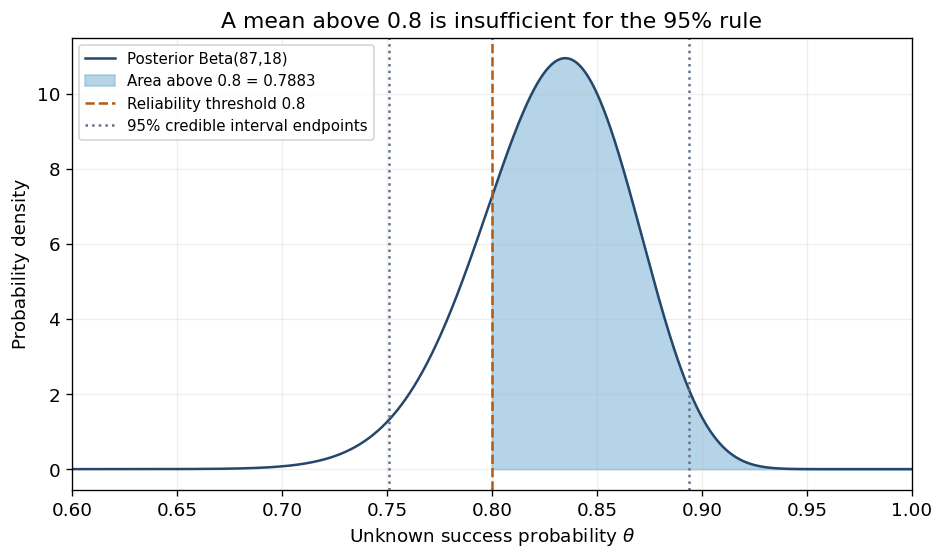

In [8]:
fig,ax=plt.subplots(figsize=(8,4.8))
theta_grid=np.linspace(0.6,0.99999,1500)
ax.plot(theta_grid,beta.pdf(theta_grid,FINAL_ALPHA,FINAL_BETA),color='#24476b',label='Posterior Beta(87,18)')
tail_grid=np.linspace(THRESHOLD,0.99999,1000)
ax.fill_between(tail_grid,beta.pdf(tail_grid,FINAL_ALPHA,FINAL_BETA),color='#84b8d8',alpha=0.6,
                label=f'Area above 0.8 = {tail_probability:.4f}')
ax.axvline(THRESHOLD,color='#b35b12',linestyle='--',label='Reliability threshold 0.8')
ax.axvline(lower,color='#64748b',linestyle=':',label='95% credible interval endpoints')
ax.axvline(upper,color='#64748b',linestyle=':')
ax.set(xlim=(0.6,1),xlabel=r'Unknown success probability $\theta$',ylabel='Probability density',
       title='A mean above 0.8 is insufficient for the 95% rule')
ax.grid(alpha=0.2)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUT/'posterior_threshold_area.png',dpi=200)
fig.savefig(OUT/'posterior_threshold_area.pdf')
plt.show()

## 6. Prior sensitivity — B4

Repeat the posterior mean and $P(\theta>0.8\mid\mathcal D)$ calculations using Beta(1,1) and Beta(8,2),
both after **Batch 1** and after **all batches**. Include Beta(2,3) as the reference.
Each alternative starts from its own original prior; do not add a new prior to Beta(87,18).

The prior means are 0.4, 0.5 and 0.8 respectively. Beta(8,2) favours high reliability and has
concentration $\alpha_0+\beta_0=10$. The posterior mean is a weighted average:

$$\frac{\alpha_0+s}{\alpha_0+\beta_0+n}
=\frac{\alpha_0+\beta_0}{\alpha_0+\beta_0+n}\frac{\alpha_0}{\alpha_0+\beta_0}
+\frac{n}{\alpha_0+\beta_0+n}\frac{s}{n}.$$

The prior's relative influence on this mean decreases as the observation count grows.
That does not imply all posterior summaries become identical across priors at a finite sample size.

In [9]:
PRIORS={'Beta(2,3)':(2,3),'Beta(1,1)':(1,1),'Beta(8,2)':(8,2)}
STAGES={'After batch 1':(6,4),'After all batches':(85,15)}
sensitivity_rows=[]
for stage,(s,f) in STAGES.items():
    for prior_name,(a0,b0) in PRIORS.items():
        a,b=update_beta(a0,b0,s,f)
        sensitivity_rows.append({'stage':stage,'prior':prior_name,'alpha':a,'beta':b,
            'posterior_mean':a/(a+b),'probability_above_0_8':float(beta.sf(THRESHOLD,a,b)),
            'ML':s/(s+f),'MAP':(a-1)/(a+b-2)})
sensitivity=pd.DataFrame(sensitivity_rows)
print(sensitivity.to_string(index=False,float_format=lambda x:f'{x:.9f}'))
uniform=sensitivity[sensitivity.prior=='Beta(1,1)']
assert np.allclose(uniform.MAP,uniform.ML)
assert not np.allclose(uniform.posterior_mean,uniform.ML)
print('\nPassed: uniform-prior MAP equals ML; posterior mean differs for these data.')
print('\nSensitivity ranges across the three priors:')
for stage in STAGES:
    subset=sensitivity[sensitivity.stage==stage]
    print(stage,{c:float(subset[c].max()-subset[c].min()) for c in ['posterior_mean','probability_above_0_8']})
sensitivity.to_csv(OUT/'prior_sensitivity.csv',index=False)

            stage     prior  alpha  beta  posterior_mean  probability_above_0_8          ML         MAP
    After batch 1 Beta(2,3)      8     7     0.533333333            0.011609914 0.600000000 0.538461538
    After batch 1 Beta(1,1)      7     5     0.583333333            0.050409574 0.600000000 0.600000000
    After batch 1 Beta(8,2)     14     6     0.700000000            0.163062304 0.600000000 0.722222222
After all batches Beta(2,3)     87    18     0.828571429            0.788266659 0.850000000 0.834951456
After all batches Beta(1,1)     86    16     0.843137255            0.881106844 0.850000000 0.850000000
After all batches Beta(8,2)     93    17     0.845454545            0.900922951 0.850000000 0.851851852

Passed: uniform-prior MAP equals ML; posterior mean differs for these data.

Sensitivity ranges across the three priors:
After batch 1 {'posterior_mean': 0.16666666666666663, 'probability_above_0_8': 0.15145239065877533}
After all batches {'posterior_mean': 0.01688311688

## 7. Interpret the findings

With a uniform Beta(1,1) prior, posterior density is proportional to the likelihood, so its maximum
occurs at ML. Since both success and failure counts are positive here:

$$\widehat\theta_{\mathrm{MAP}}=\frac{(s+1)-1}{(s+1)+(f+1)-2}=\frac{s}{n}
=\widehat\theta_{\mathrm{ML}}.$$

The full posterior remains Beta(s+1,f+1), not a point mass at ML. Its predictive success probability is
(s+1)/(n+2), generally different from s/n. With all data, ML and uniform-prior MAP are 85/100, while the
predictive probability under that prior is 86/102. Matching one point estimate does not remove uncertainty.

For the required Beta(2,3) prior, the posterior mean exceeds 0.8 but substantial posterior mass remains
below 0.8. The deployment rule requires a tail probability of at least 0.95. It is **not met**.
This does not establish that the true reliability is below 0.8.

The credible interval concerns the unknown parameter under the model and prior. It is not an interval
containing 95% of binary outcomes or a frequentist confidence-interval statement.
Changing conditions or dependent attempts could violate the assumed model; retain the supplied
fixed-parameter assumptions for this exercise and acknowledge their scope.

Complete after your run:
1. The posteriors after the three batches are **[values]**.
2. Sequential and pooled updating agree because **[explain]**.
3. Predictive probability, credible interval and threshold probability are **[values and meanings]**.
4. The Monte Carlo estimate and its standard error are **[values]**, compared with **[analytical value]**.
5. The deployment rule **[is/is not]** met because **[use the correct probability]**.
6. Prior sensitivity after 10 versus 100 attempts shows **[use table values]**.
7. My own independent check was **[what you personally verified]**.
8. My prediction versus observation was **[complete honestly]**.

For roughly two report pages, include the model and independence, derivation, posterior plot, estimate
table, uncertainty results, Monte Carlo check, decision and prior-sensitivity discussion.
Detailed draws and numerical checks can go in the supplement.

Functions to explain: update_beta takes current shapes and new counts; estimate_row summarises a posterior;
the decision cell evaluates quantiles and tail area; posterior sampling approximates the tail probability;
scaled_posterior_kernel provides a separate integration check.

Sources (official API documentation checked 12 September 2026):
- Your assignment brief and current Bayesian-learning lectures; add the exact lecture/page references you consult.
- [SciPy Beta reference](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.beta.html).
- [SciPy Bernoulli reference](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bernoulli.html).

The derivation follows the supplied model. Public documentation verifies the distribution APIs.

In [10]:
configuration={'assignment':'COMP6010 2026 Part B','prior_alpha':ALPHA0,'prior_beta':BETA0,
    'batches_are_new_counts':True,'batches':BATCHES.to_dict(orient='records'),'threshold':THRESHOLD,
    'required_probability':REQUIRED_PROBABILITY,'posterior_draw_count':POSTERIOR_DRAWS,
    'posterior_draw_seed':MC_SEED,'rng':'numpy.default_rng(seed).beta(alpha,beta,size)',
    'alternative_priors':PRIORS,'credible_interval_quantiles':[0.025,0.975],
    'versions':VERSIONS,'python':sys.version,'platform':platform.platform()}
(OUT/'configuration.json').write_text(json.dumps(configuration,indent=2))
(OUT/'requirements_observed.txt').write_text('\n'.join(f'{k}=={v}' for k,v in VERSIONS.items())+'\n')
(OUT/'README.txt').write_text("""COMP6010 Part B reproduction

Run COMP6010_Part_B_Guided_Colab.ipynb in order with Python 3, NumPy, pandas, Matplotlib and SciPy.
No external dataset, API key, GPU or trained weights are required. Computation normally takes seconds;
notebook startup, reading and rendering add overhead. Actual package versions are recorded.

input_batches.csv: new observations per batch.
posterior_updates.csv: cumulative data, posterior shapes and point estimates.
uncertainty_and_decision.csv: predictive probability, interval, tail area and rule decision.
monte_carlo_verification.csv and posterior_draws.npy: sampling verification and full parameter draws.
prior_sensitivity.csv: three priors at the two required stages.
numerical_checks.json: independent integration checks.
PNG/PDF figures: graph, prior/posteriors and final threshold area.
configuration.json and requirements_observed.txt: settings, seed and runtime versions.
ai_use_log_template.md: complete with your actual personal checks and decisions.

Save the executed notebook separately and include it alongside this evidence in the final supplement.
This export covers Part B only, not the complete assignment.
Source of all observations: COMP6010_Assignment_2026.docx.
""")
log_path=OUT/'ai_use_log_template.md'
if not log_path.exists():
    log_path.write_text("""# Part B AI-use record to complete

- Date: [enter actual date].
- Tool/model: ChatGPT; record the visible model label if available.
- Prompt: 'check this colab run output and continue'
- Assistance: Part A output review; guided Part B code, mathematical explanation and verification.
- Relevant response excerpt: 'I’ll check your Part A outputs and any unfinished sections, then prepare the guided Part B notebook.'
- Assistant checks: sequential/pooled agreement, independent kernel integration and posterior simulation.
- My independent check: [personally verify a batch update, source, integral or output].
- My evidence/source: [complete].
- My decision or change: [complete].

## Prediction versus observation
- Prediction before a NEW experiment, with date: [complete].
- Whether I had already viewed saved outputs: [state honestly].
- Setting or Monte Carlo seed: [complete].
- Observation and supporting output: [complete].
- Decision or explanation: [complete].

Keep 3–5 selected interactions across Parts A, B and C. Do not claim assistant checks as your own
or invent an earlier prediction. This is a template, not a completed declaration.
""")
archive=shutil.make_archive('COMP6010_Part_B_results','zip',root_dir=OUT)
print('Part B results ZIP created:',archive)
print('Save the notebook with outputs, and download the ZIP using the following cell.')

Part B results ZIP created: /content/COMP6010_Part_B_results.zip
Save the notebook with outputs, and download the ZIP using the following cell.


In [11]:
# Set True after reviewing the results, then run this cell to download in Colab.
DOWNLOAD_RESULTS=True
if DOWNLOAD_RESULTS:
    try:
        from google.colab import files
        files.download(archive)
    except ImportError:
        print('Outside Colab: retrieve the ZIP from',archive)
else:
    print('ZIP created but not downloaded by this cell. Set DOWNLOAD_RESULTS=True to download in Colab.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Next step

Complete the reflection prompts and save your executed notebook and results ZIP. After checking Part B,
the next stage is the proposed C2 flow-matching project: inspect a fixed random Quick, Draw! subset,
run a small training pilot in Colab, then conduct the controlled training and inference comparisons.